In [1]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
from glob import glob
import json
from pathlib import Path
import numpy as np
from collections import Counter, defaultdict
from itertools import chain
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import umap
from tqdm import tqdm
import tol_colors as tc

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfTransformer

from sentence_transformers import SentenceTransformer

plt.rcParams.update({'font.size': 12})

# load datasets
datasets = {}
for ds in glob("data/datasets/*.jsonl"):
    ds_p = Path(ds)
    datasets[ds_p.stem] = [json.loads(l) for l in ds_p.open().readlines()]

FLAG_EMOJI = {
    "DE": r"\emoji{flag-germany}",
    "EN": r"\emoji{flag-united-kingdom}",
    "FR": r"\emoji{flag-france}",
    "IT": r"\emoji{flag-italy}",
    "KO": r"\emoji{flag-south-korea}",
    "LV": r"\emoji{flag-latvia}",
    "NL": r"\emoji{flag-netherlands}",
    "PT": r"\emoji{flag-brazil}",
    "SV": r"\emoji{flag-sweden}",
    "ZH": r"\emoji{flag-china}",
    "total": r"\emoji{world-map}",
}

ALL_FRAMES = [l.strip() for l in open("data/frames.txt").readlines()]

/home/nicolas/miniconda3/envs/mfn/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Datasets composition

In [2]:
df_data = []
for k, documents in datasets.items():
    dataset_name, split_name = k.split(".")

    df_data.append({
        "dataset": dataset_name,
        "split": split_name,
        "language": documents[0]["language"].upper(),

        "documents": len(documents),
        "tokens": np.sum([len(doc["tokens"]) for doc in documents]),
        #"avg_token_per_sentence": np.mean([len(doc["tokens"]) for doc in documents]),
        #"std_token_per_sentence": np.std([len(doc["tokens"]) for doc in documents]),
        
        "annotated_frames": np.sum([len(doc["frames"]) for doc in documents]),
        "unique_frames": [f["name"] for doc in documents for f in doc["frames"]],
        #"avg_annotated_frames_per_sentence": np.mean([len(doc["frames"]) for doc in documents]),
        #"std_annotated_frames_per_sentence": np.std([len(doc["frames"]) for doc in documents]),

        "annotated_roles": np.sum([len(fr["roles"]) for doc in documents for fr in doc["frames"]]),
        "unique_roles": [f"{f['name']}.{r['name']}" for doc in documents for f in doc["frames"] for r in f["roles"]],
        #"avg_annotated_roles_per_sentence": np.mean([len(fr["roles"]) for doc in documents for fr in doc["frames"]]),
        #"std_annotated_roles_per_sentence": np.std([len(fr["roles"]) for doc in documents for fr in doc["frames"]]),
    })

df = pd.DataFrame.from_dict(df_data)

In [3]:
stats_by_language = df.groupby(["language"]).sum()[["documents", "tokens", "annotated_frames", "unique_frames", "annotated_roles", "unique_roles"]].sort_index()

splits_by_language = df.pivot(index=["language"], columns=["split"], values=["documents"]).sort_index()
splits_by_language.columns = ["test", "train", "valid"]
splits_by_language = splits_by_language.loc[:, ["train", "valid", "test"]]
splits_by_language["total"] = splits_by_language.sum(axis=1)

stats_by_language = stats_by_language.join(splits_by_language)
stats_by_language.loc["total"] = stats_by_language.sum(axis=0)

stats_by_language["frames"] = stats_by_language.apply(lambda row: f'{row["annotated_frames"]} ({len(set(row["unique_frames"]))})', axis=1)
stats_by_language["roles"] = stats_by_language.apply(lambda row: f'{row["annotated_roles"]} ({len(set(row["unique_roles"]))})', axis=1)
stats_by_language["flag"] = list(stats_by_language.index.map(FLAG_EMOJI))

stats_by_language = stats_by_language.loc[:, ["flag", "tokens", "frames", "roles", "train", "valid", "test", "total"]]
stats_by_language

,flag,tokens,frames,roles,train,valid,test,total
language,,,,,,,,
DE,\emoji{flag-germany},345247,19688 (230),35597 (848),10543,1629,2989,15161
EN,\emoji{flag-united-kingdom},112907,25951 (788),45639 (3668),3312,325,1211,4848
FR,\emoji{flag-france},206729,6536 (51),12514 (198),3733,558,1043,5334
IT,\emoji{flag-italy},25585,1255 (192),2860 (726),621,105,225,951
KO,\emoji{flag-south-korea},153391,21094 (800),38972 (4226),8407,1395,2188,11990
LV,\emoji{flag-latvia},299341,13527 (242),24836 (1131),9451,1350,2726,13527
NL,\emoji{flag-netherlands},21128,1339 (200),2054 (479),713,104,218,1035
PT,\emoji{flag-brazil},28236,7767 (519),12685 (1730),1319,171,433,1923
SV,\emoji{flag-sweden},122939,8018 (954),17209 (5174),5506,769,1694,7969


In [6]:
print(stats_by_language.to_latex())

\begin{tabular}{llrllrrrr}
\toprule
 & flag & tokens & frames & roles & train & valid & test & total \\
language &  &  &  &  &  &  &  &  \\
\midrule
DE & \emoji{flag-germany} & 345247 & 19688 (230) & 35597 (848) & 10543 & 1629 & 2989 & 15161 \\
EN & \emoji{flag-united-kingdom} & 112907 & 25951 (788) & 45639 (3668) & 3312 & 325 & 1211 & 4848 \\
FR & \emoji{flag-france} & 206729 & 6536 (51) & 12514 (198) & 3733 & 558 & 1043 & 5334 \\
IT & \emoji{flag-italy} & 25585 & 1255 (192) & 2860 (726) & 621 & 105 & 225 & 951 \\
KO & \emoji{flag-south-korea} & 153391 & 21094 (800) & 38972 (4226) & 8407 & 1395 & 2188 & 11990 \\
LV & \emoji{flag-latvia} & 299341 & 13527 (242) & 24836 (1131) & 9451 & 1350 & 2726 & 13527 \\
NL & \emoji{flag-netherlands} & 21128 & 1339 (200) & 2054 (479) & 713 & 104 & 218 & 1035 \\
PT & \emoji{flag-brazil} & 28236 & 7767 (519) & 12685 (1730) & 1319 & 171 & 433 & 1923 \\
SV & \emoji{flag-sweden} & 122939 & 8018 (954) & 17209 (5174) & 5506 & 769 & 1694 & 7969 \\
ZH & \emoj

In [6]:
mfnc_dist = np.zeros(len(ALL_FRAMES))
for k, documents in datasets.items():
    stats = Counter([f["name"] for doc in documents for f in doc["frames"]])
    for f, count in stats.items():
        mfnc_dist[ALL_FRAMES.index(f)] += count

bfn_dist = np.zeros(len(ALL_FRAMES))
stats = Counter([
    f["name"] 
    for ds in ["framenet_v17.train", "framenet_v17.valid", "framenet_v17.test"] 
    for doc in datasets[ds] 
    for f in doc["frames"]]
)
for f, count in stats.items():
    bfn_dist[ALL_FRAMES.index(f)] += count

print("BFN sentence per frame", np.median(bfn_dist))
print("BFN sentence per frame", np.median(mfnc_dist))

BFN sentence per frame 3.0
BFN sentence per frame 25.0


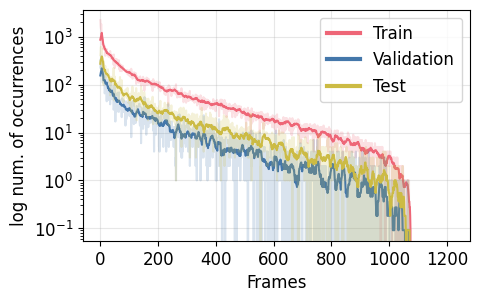

In [7]:
distributions = defaultdict(lambda: np.zeros(len(ALL_FRAMES)))

df_data = []
for k, documents in datasets.items():
    dataset_name, split_name = k.split(".")
    stats = Counter([f["name"] for doc in documents for f in doc["frames"]])

    for f, count in stats.items():
        distributions[split_name][ALL_FRAMES.index(f)] += count

dist_per_language = defaultdict(lambda: np.zeros(len(ALL_FRAMES)))
for documents in datasets.values():
    language = documents[0]["language"]
    stats = Counter([f["name"] for doc in documents for f in doc["frames"]])
    for f, count in stats.items():
        dist_per_language[language][ALL_FRAMES.index(f)] += count
dist_per_language = dict(sorted(dist_per_language.items(), key=lambda t: t[0]))

train_d, valid_d, test_d = distributions["train"], distributions["valid"], distributions["test"]

dist = train_d + valid_d + test_d
sort_idx = (-dist).argsort()

fig, ax = plt.subplots(figsize=(5, 3))
for split, d, color in zip(["Train", "Validation", "Test"], [train_d, valid_d, test_d], [tc.bright.red, tc.bright.blue, tc.bright.yellow]):
    ax.plot(d[sort_idx], alpha=0.2, c=color)

    smooth_d = np.convolve(d[sort_idx], np.ones(11) / 11, "same")
    ax.plot(smooth_d, c=color, label=split.capitalize())

ax.set_yscale("log")
ax.grid(alpha=0.3)
for line in fig.legend(loc="upper right", bbox_to_anchor=(0.5, 0.5, 0.4, 0.38)).get_lines():
    line.set_linewidth(3.0)

ax.set_xlabel("Frames")
ax.set_ylabel("log num. of occurrences")

#fig.savefig("figures/splits_occ.pdf", bbox_inches = "tight", dpi=600)
plt.show()

In [8]:
all_distributions = np.array(list(distributions.values())).sum(axis=0)

never_appearing = (all_distributions == 0).sum()
print(f"{never_appearing} frames (~{(never_appearing/all_distributions.shape[0]) * 100:2.3f}%) never appear.")

for i in (-all_distributions).argsort()[:10]:
    print(f"{ALL_FRAMES[i].rjust(20)}: {all_distributions[i]}")

for i in (all_distributions).argsort()[never_appearing:never_appearing + 25]:
    print(f"{ALL_FRAMES[i].rjust(20)}: {all_distributions[i]}")

151 frames (~12.367%) never appear.
           Causation: 2873.0
           Statement: 2534.0
      Calendric_unit: 2439.0
             Telling: 2437.0
   Political_locales: 2107.0
              People: 1942.0
            Evidence: 1291.0
             Request: 1247.0
            Arriving: 1068.0
          Possession: 1056.0
            Offshoot: 1.0
Freeing_from_confinement: 1.0
  Deception_scenario: 1.0
 Employment_continue: 1.0
      Employment_end: 1.0
Margin_of_resolution: 1.0
           Explosion: 1.0
  Causation_scenario: 1.0
Locale_by_characteristic_entity: 1.0
   Change_post-state: 1.0
       Optical_image: 1.0
   Change_resistance: 1.0
      Co-association: 1.0
        Noncombatant: 1.0
              Plants: 1.0
             Funding: 1.0
        Set_relation: 1.0
Mathematical_relationship: 1.0
        Appellations: 1.0
 Medical_instruments: 1.0
     Visit_host_stay: 1.0
Activity_paused_state: 2.0
        Elusive_goal: 2.0
       Knot_creation: 2.0
       Bail_decision: 2.0


In [9]:
frames_per_doc = [len(doc["frames"]) for documents in datasets.values() for doc in documents]
print(f"{np.mean(frames_per_doc):1.2f} \\pm {np.std(frames_per_doc):1.2f} frames per document")
roles_per_doc = [len(fr["roles"]) for documents in datasets.values() for doc in documents for fr in doc["frames"]]
print(f"{np.mean(roles_per_doc):1.2f} \\pm {np.std(roles_per_doc):1.2f} frames per document")

1.65 \pm 1.75 frames per document
1.89 \pm 0.80 frames per document


In [10]:
tokens_per_language = defaultdict(list)
frames_per_language = defaultdict(list)
roles_per_language = defaultdict(list)
for documents in datasets.values():
    language = documents[0]["language"].upper()
    for doc in documents:
        tokens_per_language[language].append(len(doc["tokens"]))
        frames_per_language[language].append(len(doc["frames"]))
        #for fr in doc["frames"]:
        roles_per_language[language].append(sum([len(fr["roles"]) for fr in doc["frames"]]))

tokens_per_language = dict(sorted(tokens_per_language.items(), key=lambda t: t[0]))
frames_per_language = dict(sorted(frames_per_language.items(), key=lambda t: t[0]))
roles_per_language = dict(sorted(roles_per_language.items(), key=lambda t: t[0]))

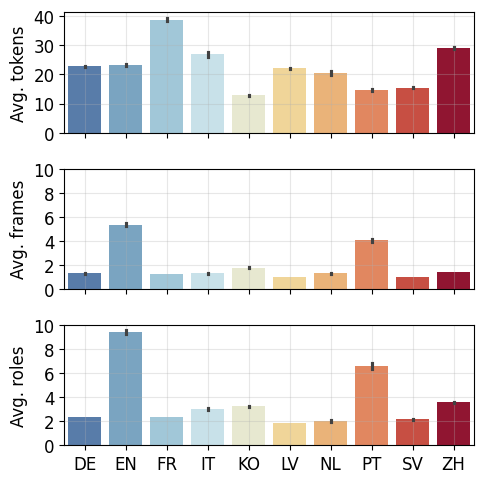

In [11]:
fig, axs = plt.subplots(3, 1, figsize=(5, 5))

sns.barplot(tokens_per_language, palette="tol.sunset_discrete", ax=axs[0])
axs[0].grid(alpha=0.3)
axs[0].set_xticklabels([])
axs[0].set_ylabel("Avg. tokens")
y = list(range(0, 50, 10))
axs[0].set_yticks(y, labels=y)

sns.barplot(frames_per_language, palette="tol.sunset_discrete", ax=axs[1])
axs[1].grid(alpha=0.3)
axs[1].set_ylim(0, 10)
axs[1].set_xticklabels([])
axs[1].set_ylabel("Avg. frames")
y = list(range(0, 12, 2))
axs[1].set_yticks(y, labels=y)

sns.barplot(roles_per_language, palette="tol.sunset_discrete", ax=axs[2])
axs[2].set_ylim(0, 10)
axs[2].grid(alpha=0.3)
axs[2].set_ylabel("Avg. roles")
y = list(range(0, 12, 2))
axs[2].set_yticks(y, labels=y)
fig.tight_layout()

fig.savefig("figures/lang_sentence_stats.pdf", bbox_inches = "tight", dpi=600)

In [12]:
for lang, dist in dist_per_language.items():
    print(lang, ":", (dist == 0).sum(), "frames never appearing")

de : 991 frames never appearing
en : 433 frames never appearing
fr : 1170 frames never appearing
it : 1029 frames never appearing
ko : 421 frames never appearing
lv : 979 frames never appearing
nl : 1021 frames never appearing
pt : 702 frames never appearing
sv : 267 frames never appearing
zh : 637 frames never appearing


In [13]:
1 - (433 / len(ALL_FRAMES))

0.6453726453726454

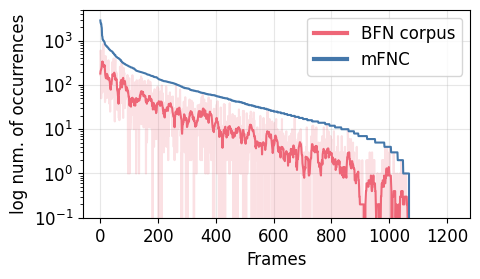

In [14]:
dist_per_language = defaultdict(lambda: np.zeros(len(ALL_FRAMES)))
for documents in datasets.values():
    language = documents[0]["language"]
    stats = Counter([f["name"] for doc in documents for f in doc["frames"]])
    for f, count in stats.items():
        dist_per_language[language][ALL_FRAMES.index(f)] += count
dist_per_language = dict(sorted(dist_per_language.items(), key=lambda t: t[0]))

fig, ax = plt.subplots(figsize=(5, 2.7))

d = dist_per_language["en"][sort_idx]
smooth_d = np.convolve(d, np.ones(10) / 10, "same")
ax.plot(d, c=tc.bright.red, alpha=0.2)
ax.plot(smooth_d, c=tc.bright.red, label="BFN corpus")

d = np.vstack([d for d in dist_per_language.values()]).sum(axis=0)[sort_idx]
smooth_d = np.convolve(d, np.ones(10) / 10, "same")
ax.plot(d, c=tc.bright.blue, label="mFNC")

ax.set_yscale("log")
ax.grid(alpha=0.3)
for line in fig.legend(loc="upper right", bbox_to_anchor=(0.5, 0.5, 0.4, 0.38)).get_lines():
    line.set_linewidth(3.0)
ax.set_ylim(1e-1, 5000)

ax.set_xlabel("Frames")
ax.set_ylabel("log num. of occurrences")

fig.savefig("figures/bfn_vs_mfnc_dist.pdf", bbox_inches = "tight", dpi=600)

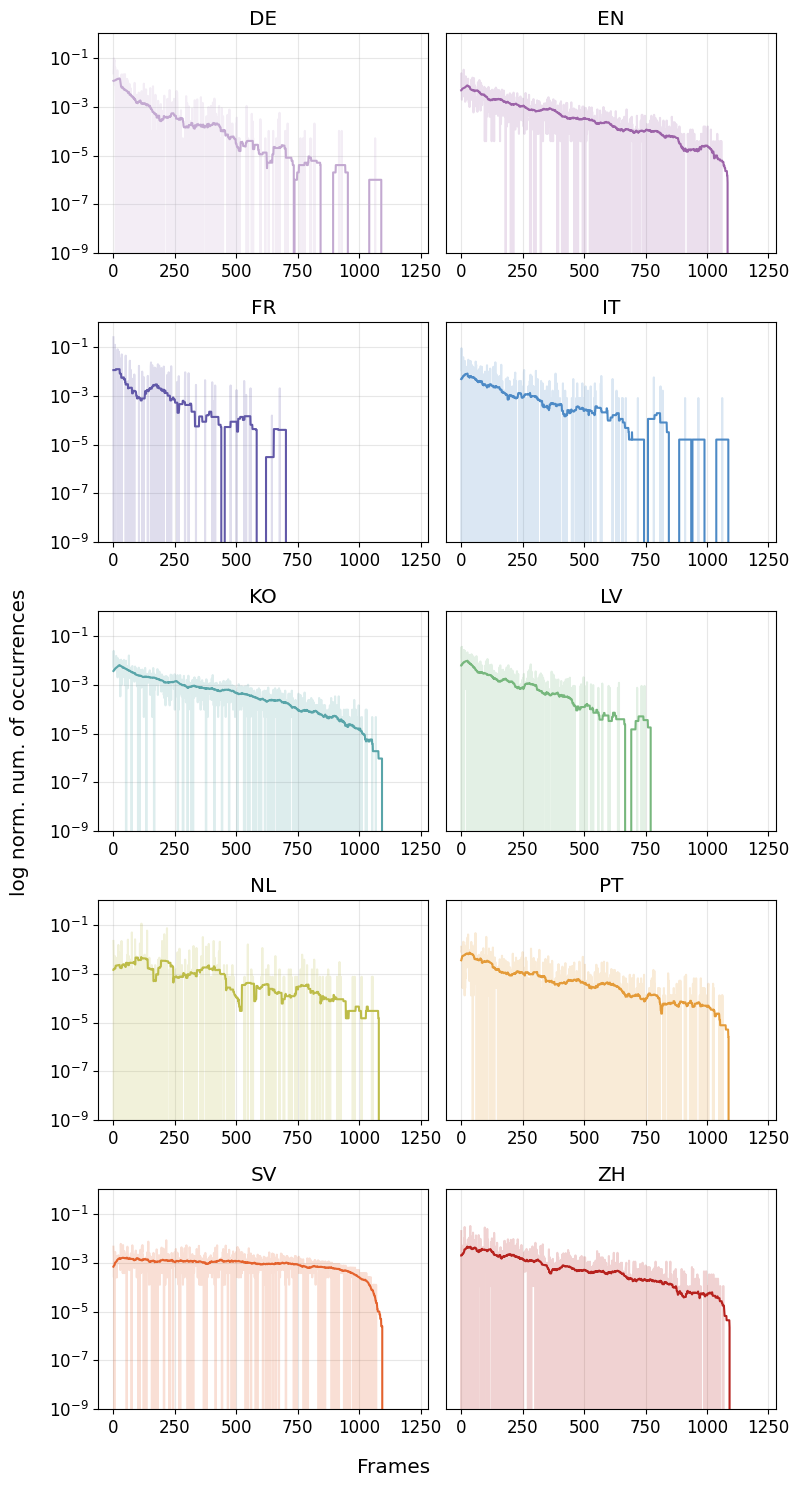

In [16]:
dist_per_language = defaultdict(lambda: np.zeros(len(ALL_FRAMES)))
for documents in datasets.values():
    language = documents[0]["language"]
    stats = Counter([f["name"] for doc in documents for f in doc["frames"]])
    for f, count in stats.items():
        dist_per_language[language][ALL_FRAMES.index(f)] += count
dist_per_language = dict(sorted(dist_per_language.items(), key=lambda t: t[0]))

fig, axs = plt.subplots(5, 2, figsize=(8, 15))

for i, ((lang, d), ax) in enumerate(zip(dist_per_language.items(), axs.flatten())):
    d = d / d.sum()
    ax.plot(d[sort_idx], alpha=0.2, c=mpl.colormaps["tol.rainbow"]((i + 1) / 11))
    
    smooth_d = np.convolve(d[sort_idx], np.ones(50) / 50, "same")
    ax.plot(smooth_d, c=mpl.colormaps["tol.rainbow"]((i + 1) / 11), label=split.capitalize())

    ax.set_title(lang.upper())
    ax.set_yscale("log")
    ax.grid(alpha=0.3)
    ax.set_ylim(10e-10, 1)

    if (i % 2) != 0:
        ax.get_yaxis().set_visible(False)

fig.supylabel("log norm. num. of occurrences")
fig.supxlabel("Frames")

fig.tight_layout()
fig.savefig("figures/splits_lang_occ.pdf", bbox_inches = "tight", dpi=600)
plt.show()

In [17]:
#model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2", device="cuda:0")

In [18]:
dist_per_language

{'de': array([0., 0., 0., ..., 0., 0., 0.], shape=(1221,)),
 'en': array([ 6., 37.,  0., ...,  0., 29.,  0.], shape=(1221,)),
 'fr': array([0., 0., 0., ..., 0., 0., 0.], shape=(1221,)),
 'it': array([13.,  1.,  0., ...,  0.,  0.,  0.], shape=(1221,)),
 'ko': array([18., 48.,  4., ...,  0., 26.,  1.], shape=(1221,)),
 'lv': array([15.,  0.,  0., ...,  0., 16.,  0.], shape=(1221,)),
 'nl': array([3., 0., 0., ..., 0., 3., 0.], shape=(1221,)),
 'pt': array([ 8., 19.,  1., ...,  0., 15.,  0.], shape=(1221,)),
 'sv': array([ 8.,  8., 14., ...,  9., 10.,  2.], shape=(1221,)),
 'zh': array([12.,  3.,  6., ...,  0., 20.,  0.], shape=(1221,))}

In [70]:
mlb = MultiLabelBinarizer().fit([[f,] for f in ALL_FRAMES])

language_vectors = defaultdict(list)

for documents in datasets.values():
    language = documents[0]["language"]

    for doc in documents:
        language_vectors[language].append(mlb.transform([[f["name"] for f in doc["frames"]],]))

language_vectors = {l: np.array(values)[:, 0, :].sum(axis=0) for l, values in sorted(language_vectors.items(), key=lambda i: i[0])}
language_vectors = {l: values / values.sum() for l, values in language_vectors.items()}

In [85]:
n = len(language_vectors)
sim = np.zeros((n, n))

vectors = list(language_vectors.values())
for i in range(n):
    i_vec = vectors[i]
    
    for j in range(i, n):
        j_vec = vectors[j]
        sim_ij = np.log(np.sqrt(i_vec * j_vec).sum())
        sim[i, j] = sim_ij
        sim[j, i] = sim_ij

<Axes: >

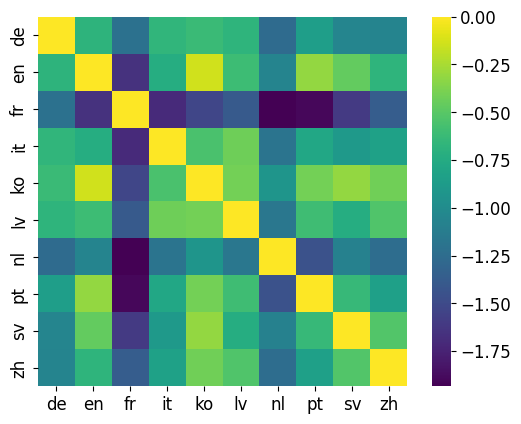

In [86]:
languages = list(language_vectors.keys())
sns.heatmap(sim, xticklabels=languages, yticklabels=languages, square=True, cmap="viridis")

In [47]:
l_vecs = np.array(language_vectors["it"])[:, 0, :]
tfidf = TfidfTransformer().fit(l_vecs)

In [53]:
tfidf.transform(l_vecs.sum(axis=0, keepdims=True)).todense()

matrix([[0.09412543, 0.00993975, 0.        , ..., 0.        , 0.        ,
         0.        ]], shape=(1, 1221))

In [686]:
mlb = MultiLabelBinarizer().fit([[f,] for f in ALL_FRAMES])

X_frame_vectors = defaultdict(list)
X_semantic_vectors = defaultdict(list)
for documents in datasets.values():
    language = documents[0]["language"]
    
    #X_semantic_vectors[language].append(model.encode([d["sentence"] for d in documents], batch_size=4, show_progress_bar=True))
    
    for doc in documents:
        X_frame_vectors[language].append(mlb.transform([[f["name"] for f in doc["frames"]],]))

# compute tfidf centroids and normalize for cosine similarity
X_frame_vectors = {l: np.vstack(vecs) for l, vecs in sorted(X_frame_vectors.items(), key=lambda t: t[0])}
tfids_t = TfidfTransformer().fit(np.vstack(list(X_frame_vectors.values())))
X_frame_vectors = np.stack([x.mean(axis=0) for x in X_frame_vectors.values()])
X_frame_vectors /= np.linalg.norm(X_frame_vectors, axis=1).reshape(-1, 1)
frame_sim = (X_frame_vectors @ X_frame_vectors.T)

#X_semantic_vectors = {l: np.vstack(vecs).mean(axis=0) for l, vecs in sorted(X_semantic_vectors.items(), key=lambda t: t[0])}
#X_semantic_vectors = np.stack(list(X_semantic_vectors.values()))
#X_semantic_vectors /= np.linalg.norm(X_semantic_vectors, axis=1).reshape(-1, 1)
#sem_sim = (X_s @ X_s.T)

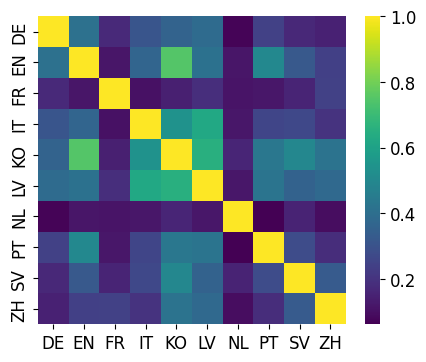

In [707]:
fig, ax = plt.subplots(figsize=(5, 4))

sns.heatmap(frame_sim, xticklabels=languages, yticklabels=languages, square=True, cmap="viridis")
fig.savefig("figures/annotation_frame_similarity.pdf", bbox_inches = "tight", dpi=600)

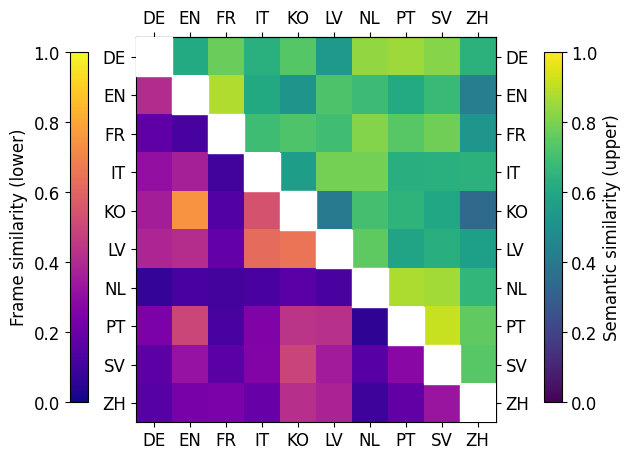

In [486]:
fig, ax = plt.subplots(figsize=(6, 5))
fig.subplots_adjust(left=0.15, right=0.75)
n = len(languages)
combined = np.full((n, n), np.nan)
for i in range(n):
    for j in range(n):
        if i < j:
            combined[i, j] = sem_sim[i, j]
        elif i > j:
            combined[i, j] = frame_sim[i, j]

upper_mask = np.ones((n, n), dtype=bool)
for i in range(n):
    for j in range(n):
        if i < j:
            upper_mask[i, j] = False
upper_data = np.ma.masked_where(upper_mask | np.eye(n, dtype=bool), combined)
im1 = ax.imshow(upper_data, cmap="viridis", vmin=0, vmax=1, aspect="auto")

lower_mask = np.ones((n, n), dtype=bool)
for i in range(n):
    for j in range(n):
        if i > j:
            lower_mask[i, j] = False
lower_data = np.ma.masked_where(lower_mask | np.eye(n, dtype=bool), combined)
im2 = ax.imshow(lower_data, cmap="plasma", vmin=0, vmax=1, aspect="auto")

for i in range(n):
    ax.add_patch(plt.Rectangle((i - 0.5, i - 0.5), 1, 1, color="white", zorder=3))

# --- Axes: bottom + left ---
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(languages, ha="center", va="top")
ax.set_yticklabels(languages)

# --- Top x-axis ---
ax2 = ax.secondary_xaxis("top")
ax2.set_xticks(range(n))
ax2.set_xticklabels(languages, ha="center", va="bottom")

# --- Right y-axis ---
ax3 = ax.secondary_yaxis("right")
ax3.set_yticks(range(n))
ax3.set_yticklabels(languages)

# --- Left colorbar (plasma / frame sim) ---
cax_left = fig.add_axes([0.04, 0.15, 0.03, 0.7])
sm2 = mpl.cm.ScalarMappable(cmap="plasma", norm=mpl.colors.Normalize(vmin=0, vmax=1))
sm2.set_array([])
cb2 = fig.colorbar(sm2, cax=cax_left)
cb2.set_label("Frame similarity (lower)")
cax_left.yaxis.set_ticks_position("left")
cax_left.yaxis.set_label_position("left")

# --- Right colorbar (viridis / semantic sim) ---
cax_right = fig.add_axes([0.83, 0.15, 0.03, 0.7])
cb1 = fig.colorbar(im1, cax=cax_right)
cb1.set_label("Semantic similarity (upper)")

#fig.tight_layout()
fig.savefig("figures/annotation_frame_similarity.pdf", bbox_inches = "tight", dpi=600)
plt.show()

In [796]:
table_template = """\\begin{{subtable}}[b]{{0.5\linewidth}}
    \centering
       {content}
    \end{{subtable}}%"""

latex = []
for lang, dist in dist_per_language.items():
    table = pd.DataFrame()
    top_k = (-dist).argsort()[:10]
    #table.loc[lang.upper()] = [f"\\textsc{{{ALL_FRAMES[k].replace('_', '\\_')}}} {int(dist[k])}" for k in top_k]
    table["\\#"] = [int(dist[k]) for k in top_k]
    table["Frame"] = [f"\\textsc{{{ALL_FRAMES[k].replace('_', '\\_')}}}" for k in top_k]
    latex.append(table_template.format(content=table.to_latex(index=False, caption=lang.upper())).replace("\\begin{table}", "").replace("\\end{table}", ""))

<>:1: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:1: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_233228/129460334.py:1: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  table_template = """\\begin{{subtable}}[b]{{0.5\linewidth}}


In [798]:
print("\n".join(latex))

\begin{subtable}[b]{0.5\linewidth}
    \centering
       
\caption{DE}
\begin{tabular}{rl}
\toprule
\# & Frame \\
\midrule
1852 & \textsc{Calendric\_unit} \\
1623 & \textsc{Telling} \\
1565 & \textsc{People} \\
1368 & \textsc{Political\_locales} \\
796 & \textsc{Request} \\
768 & \textsc{Statement} \\
602 & \textsc{Judgment\_communication} \\
457 & \textsc{Causation} \\
422 & \textsc{Employing} \\
412 & \textsc{Collaboration} \\
\bottomrule
\end{tabular}


    \end{subtable}%
\begin{subtable}[b]{0.5\linewidth}
    \centering
       
\caption{EN}
\begin{tabular}{rl}
\toprule
\# & Frame \\
\midrule
842 & \textsc{Weapon} \\
672 & \textsc{Locale\_by\_use} \\
603 & \textsc{Statement} \\
556 & \textsc{Political\_locales} \\
451 & \textsc{Leadership} \\
436 & \textsc{Calendric\_unit} \\
398 & \textsc{Buildings} \\
381 & \textsc{Quantified\_mass} \\
361 & \textsc{Cardinal\_numbers} \\
327 & \textsc{Temporal\_collocation} \\
\bottomrule
\end{tabular}


    \end{subtable}%
\begin{subtable}[b]{0.

# Tokenization noise

In [29]:
from sacremoses import MosesTokenizer
from difflib import SequenceMatcher

In [9]:
unified_datasets = defaultdict(list)
for k, v in datasets.items():
    unified_datasets[k.split(".")[0]].extend(v)

In [64]:
tok_data = []
for d, docs in unified_datasets.items():
    if docs[0]["language"] == "zh":
        break
    tok = MosesTokenizer(lang=docs[0]["language"])

    precision, recall, f1 = [], [], []
    for doc in docs:
        tokens = doc["tokens"]
        re_tokens = tok.tokenize(doc["sentence"])
        
        sm = SequenceMatcher(None, tokens, re_tokens, autojunk=False)
        matches = sum(block.size for block in sm.get_matching_blocks())

        p, r = matches / len(re_tokens), matches / len(tokens)
        
        precision.append(p)
        recall.append(r)
        f1.append((2 * p * r) / (p + r) if (p + r) > 0 else 0.0)

    tok_data.append({
        "language": docs[0]["language"],
        "precision": np.mean(precision),
        "recall": np.mean(recall),
        "f1": np.mean(f1),
    })

In [63]:
pd.DataFrame.from_dict(tok_data)

,language,precision,recall,f1
0,it,0.932826,0.945039,0.938541
1,fr,0.999932,0.999868,0.999899
2,de,0.969361,0.970031,0.969662
3,en,0.973690,0.977884,0.975653
4,nl,0.987289,0.985594,0.986223
5,zh,0.376887,0.086363,0.137423
6,ko,0.750107,0.853421,0.797440
7,sv,0.996827,0.997556,0.997151
8,lv,0.987365,0.985894,0.986545
9,pt,0.995413,0.994955,0.995155
